In [1]:
# ============================================
# Exploratory Data Analysis
# Vessel Arrival Delay Prediction
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (10,6)

# Set plot style
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/vessel_arrival_delay.csv")

df.head()

,Voyage_ID,Carrier,Vessel_Name,Vessel_Type,Origin_Port,Destination_Port,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Season,Customs_Clearance_Risk,Actual_Delay_Hours,Late_Arrival
0,V14846,COSCO,Mary Voyager,Bulk Carrier,Hamburg,Los Angeles,4659,16.1,1.7,14.4,19,88.6,45.7,5.2,805.55,1.1,Spring,Medium,16.6,1
1,V14121,Yang Ming,David Voyager,LNG Carrier,Los Angeles,Antwerp,5571,13.7,8.6,13.9,10,55.9,47.9,6.4,539.09,7.9,Autumn,Low,24.4,1
2,V14861,COSCO,Heather Voyager,Bulk Carrier,Singapore,Mumbai,3422,8.9,0.3,12.3,22,95.3,0.3,9.2,650.76,12.6,Spring,Low,26.9,1
3,V00885,ONE,Rachel Voyager,Oil Tanker,Colombo,Mumbai,1300,4.0,NaN,17.7,25,96.1,NaN,NaN,NaN,NaN,Summer,High,25.2,1
4,V00412,CMA CGM,Karen Voyager,Container,Busan,Shanghai,11140,42.2,18.9,15.6,15,64.0,41.3,6.2,669.18,3.2,Autumn,High,29.9,1


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 15100
Columns : 20


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Voyage_ID               15100 non-null  str    
 1   Carrier                 15100 non-null  str    
 2   Vessel_Name             15100 non-null  str    
 3   Vessel_Type             15100 non-null  str    
 4   Origin_Port             15100 non-null  str    
 5   Destination_Port        15100 non-null  str    
 6   Distance_NM             15100 non-null  int64  
 7   Scheduled_Transit_Days  15100 non-null  float64
 8   Departure_Delay_Hours   14550 non-null  float64
 9   Average_Speed_Knots     15100 non-null  float64
 10  Vessel_Age              15100 non-null  int64  
 11  Cargo_Load_Percentage   15100 non-null  float64
 12  Port_Congestion_Index   14550 non-null  float64
 13  Weather_Severity        14550 non-null  float64
 14  Fuel_Price_USD          14550 non-null  float64
 

In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Departure_Delay_Hours     550
Port_Congestion_Index     550
Weather_Severity          550
Fuel_Price_USD            550
Historical_Route_Delay    550
dtype: int64

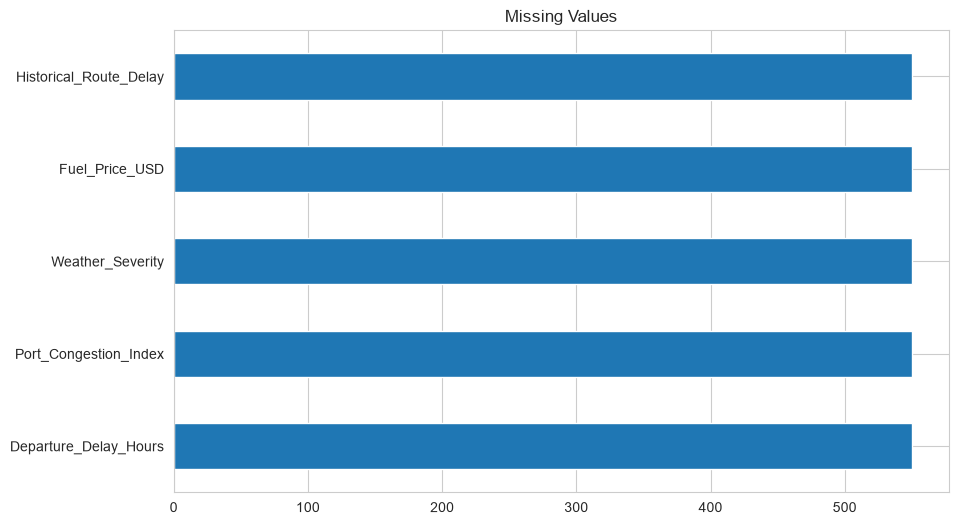

In [6]:
missing.sort_values().plot(kind="barh")

plt.title("Missing Values")

plt.show()

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 99


In [8]:
df.describe()

,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Actual_Delay_Hours,Late_Arrival
count,15100.000000,15100.000000,14550.000000,15100.000000,15100.000000,15100.000000,14550.000000,14550.000000,14550.000000,14550.000000,15100.000000,15100.000000
mean,6305.556490,18.486450,6.249849,18.000146,15.472781,69.824437,50.018247,4.977141,650.725260,8.259299,21.783199,0.894106
std,3335.876651,10.378833,4.527758,3.482798,8.617855,17.307196,28.957550,2.900027,116.092216,5.526371,12.282576,0.307712
min,500.000000,1.100000,0.000000,12.000000,1.000000,40.000000,0.000000,0.000000,450.050000,0.000000,0.100000,0.000000
25%,3403.000000,9.700000,2.500000,15.000000,8.000000,54.800000,24.700000,2.500000,549.632500,3.900000,16.000000,1.000000
50%,6332.500000,18.000000,5.900000,18.000000,15.000000,69.900000,50.150000,4.900000,651.745000,8.000000,21.200000,1.000000
75%,9223.000000,26.300000,9.400000,21.000000,23.000000,84.700000,75.200000,7.500000,751.315000,12.100000,26.500000,1.000000
max,11999.000000,47.700000,28.400000,24.000000,30.000000,100.000000,100.000000,10.000000,849.870000,30.100000,359.100000,1.000000


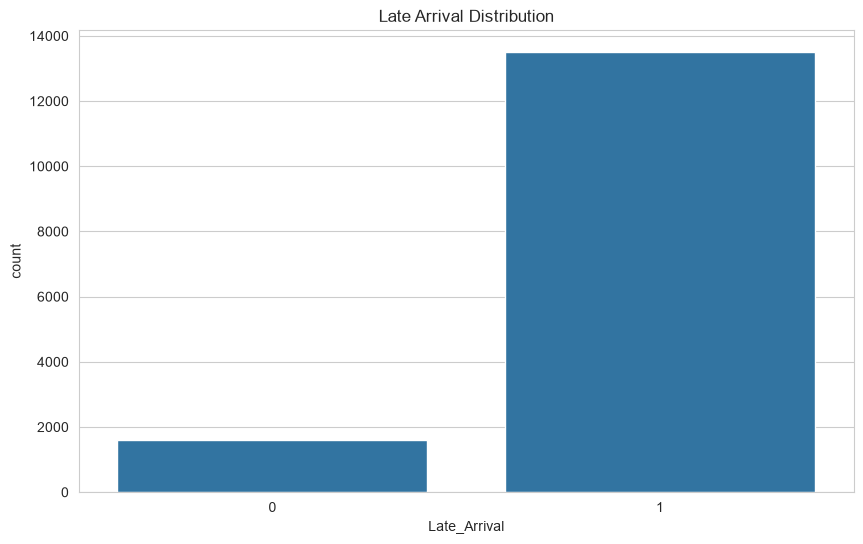

In [9]:
sns.countplot(
    data=df,
    x="Late_Arrival"
)

plt.title("Late Arrival Distribution")

plt.show()

In [10]:
df["Late_Arrival"].value_counts(normalize=True)*100

Late_Arrival
1    89.410596
0    10.589404
Name: proportion, dtype: float64

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Distance_NM', 'Scheduled_Transit_Days', 'Departure_Delay_Hours',
       'Average_Speed_Knots', 'Vessel_Age', 'Cargo_Load_Percentage',
       'Port_Congestion_Index', 'Weather_Severity', 'Fuel_Price_USD',
       'Historical_Route_Delay', 'Actual_Delay_Hours', 'Late_Arrival'],
      dtype='str')

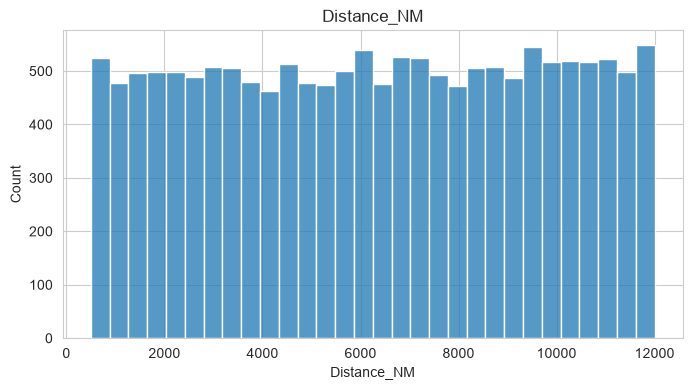

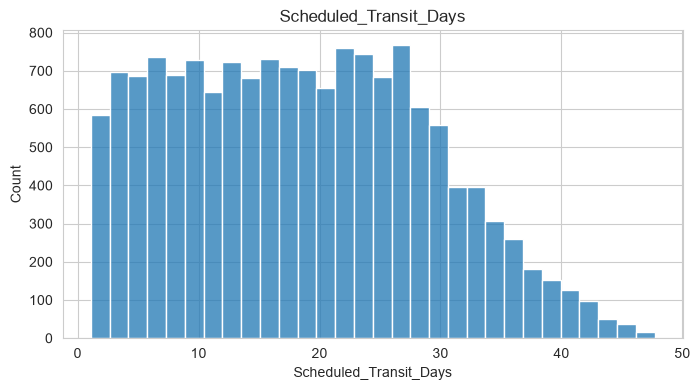

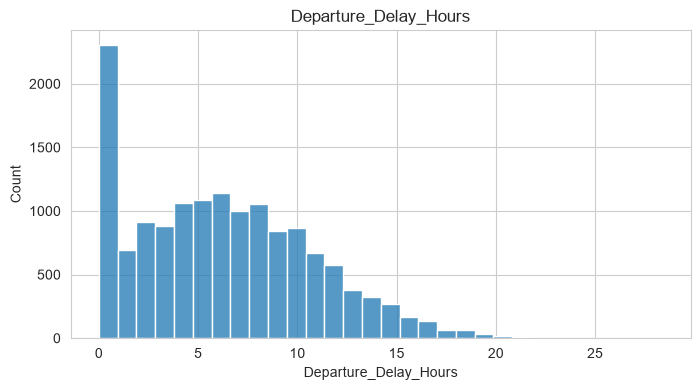

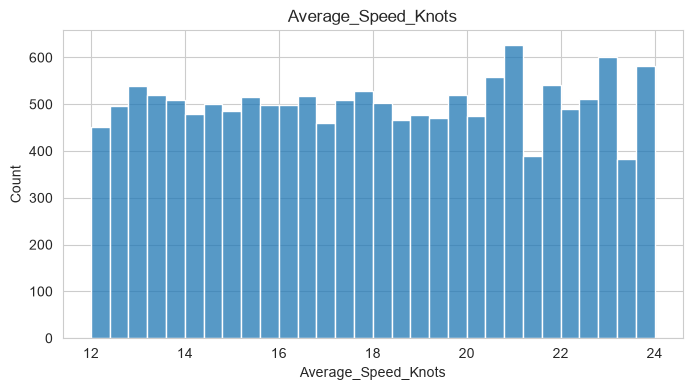

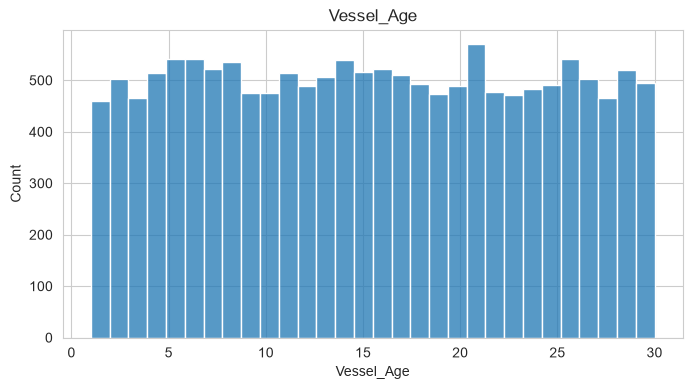

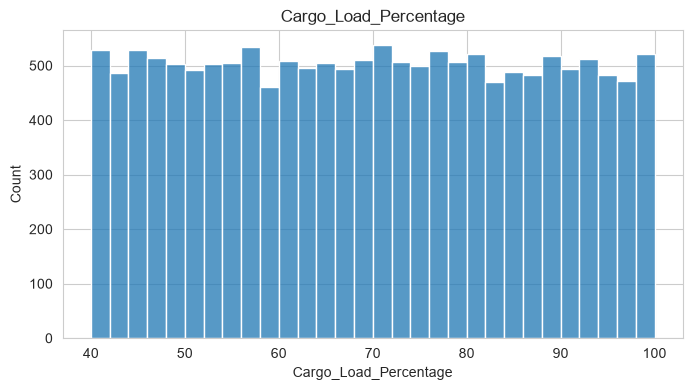

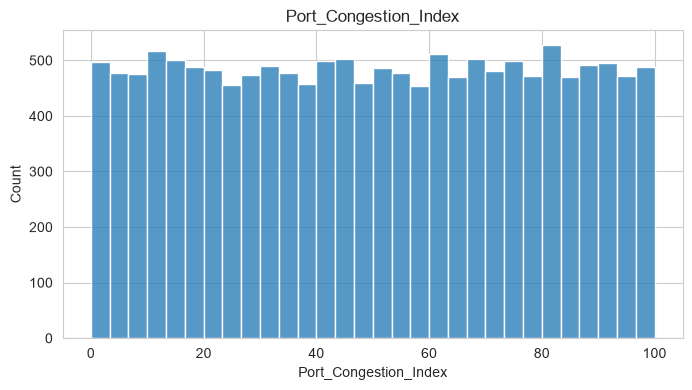

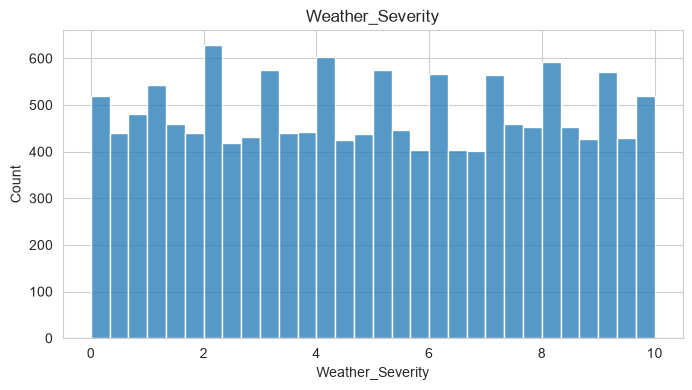

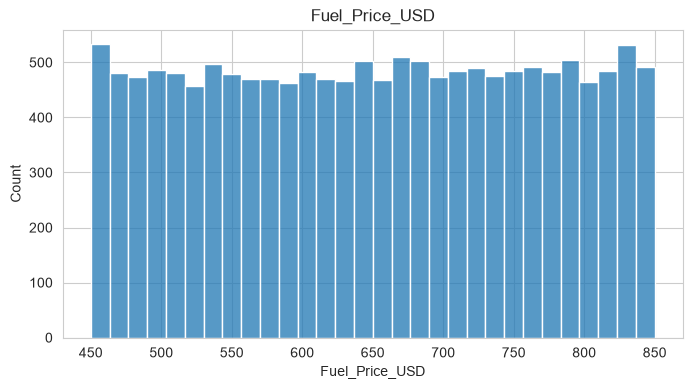

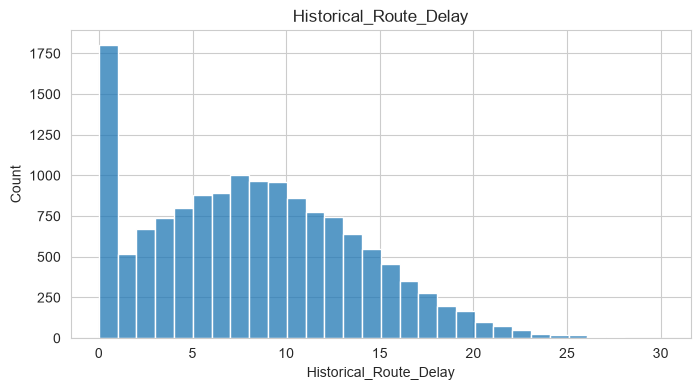

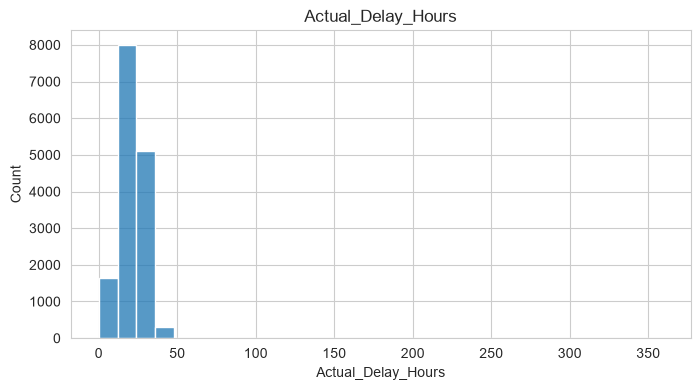

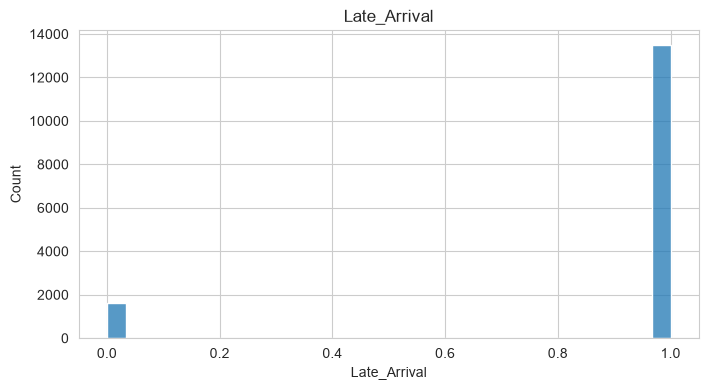

In [12]:
for column in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[column], bins=30)

    plt.title(column)

    plt.show()

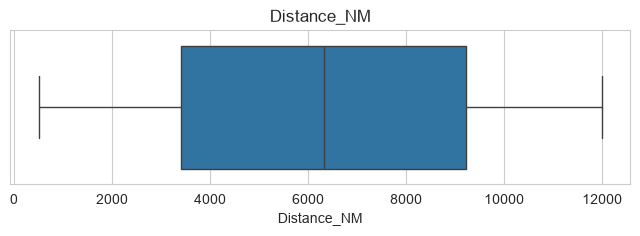

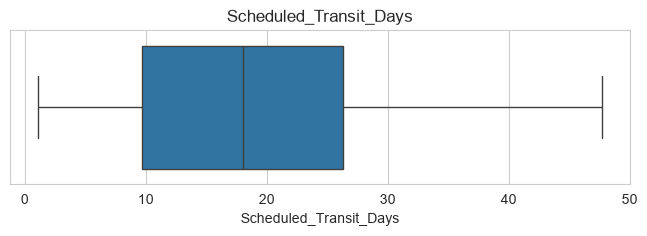

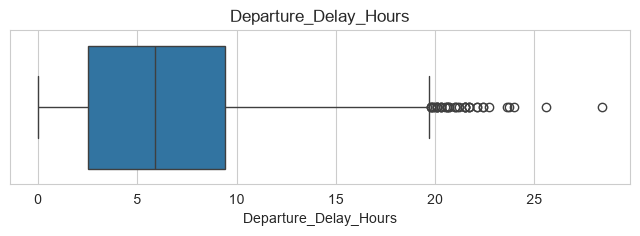

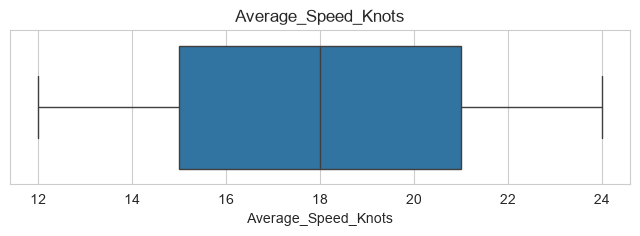

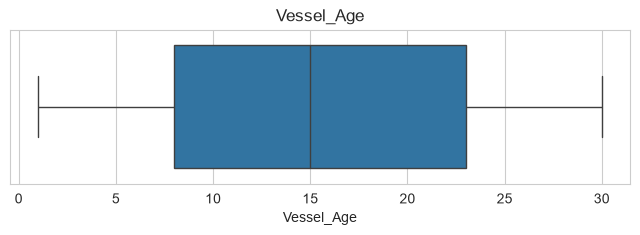

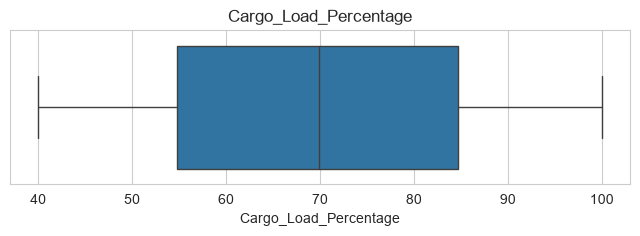

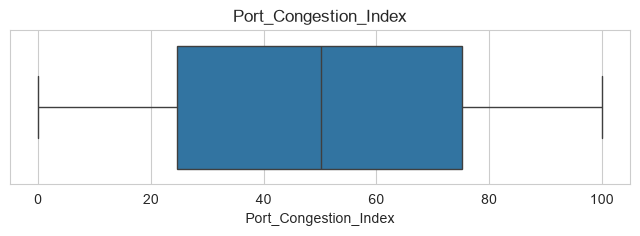

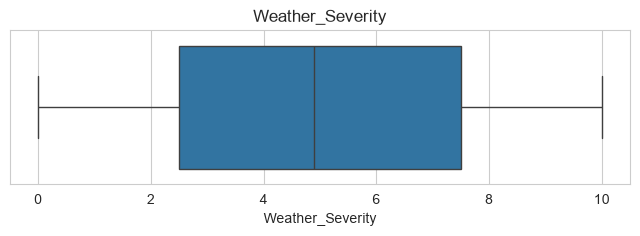

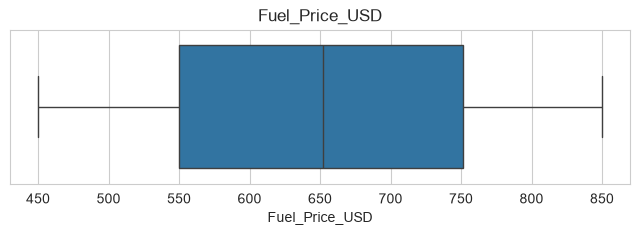

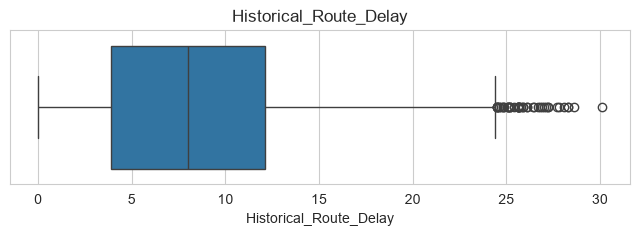

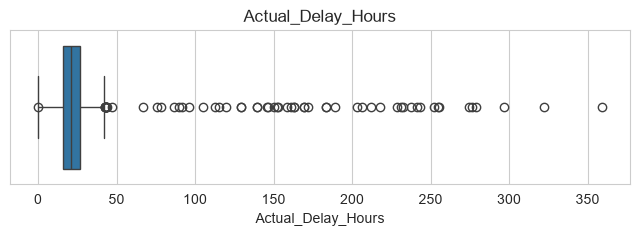

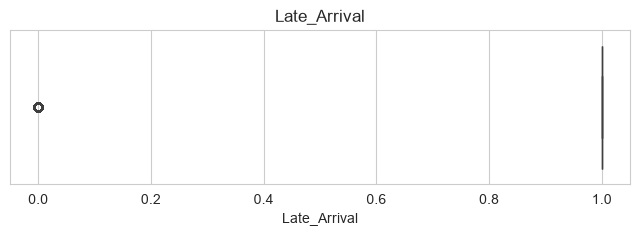

In [13]:
for column in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

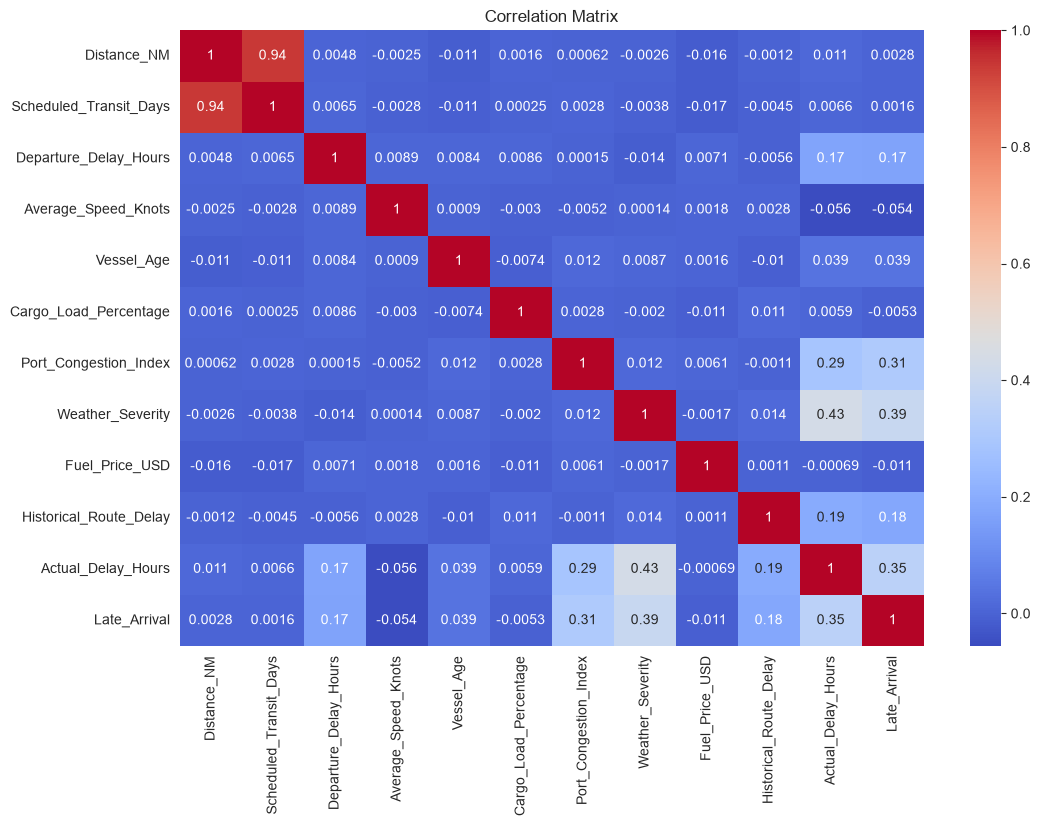

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

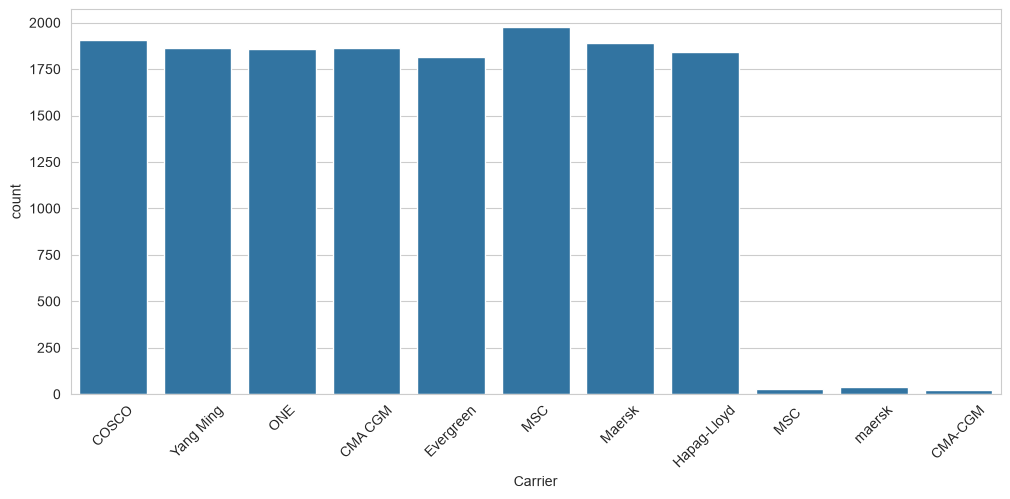

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Carrier"
)

plt.xticks(rotation=45)

plt.show()

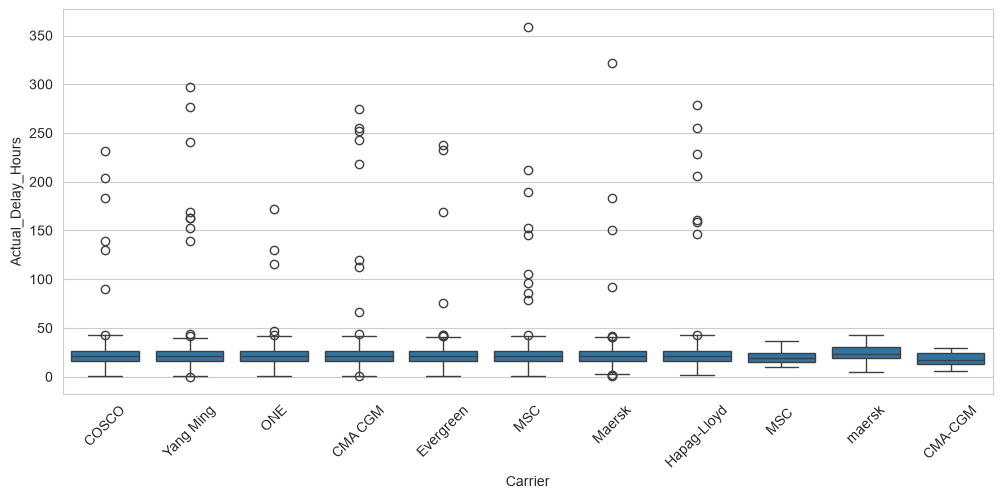

In [17]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Carrier",
    y="Actual_Delay_Hours"
)

plt.xticks(rotation=45)

plt.show()

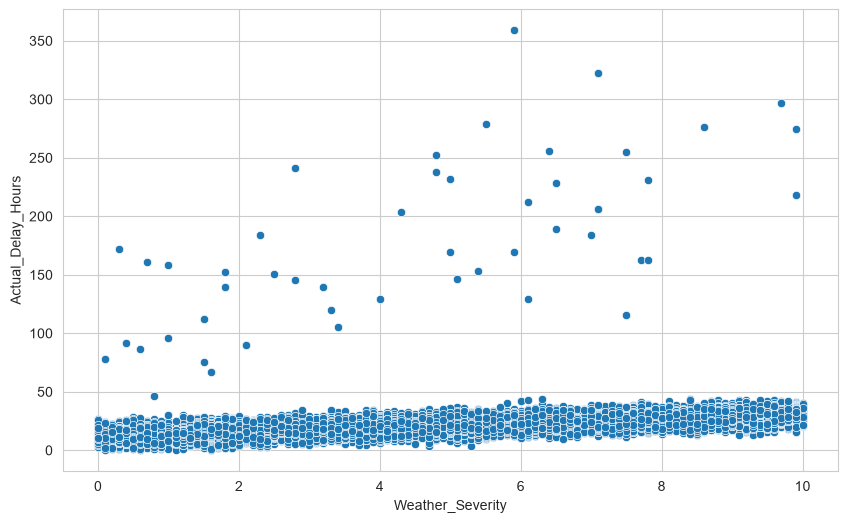

In [18]:
sns.scatterplot(
    data=df,
    x="Weather_Severity",
    y="Actual_Delay_Hours"
)

plt.show()

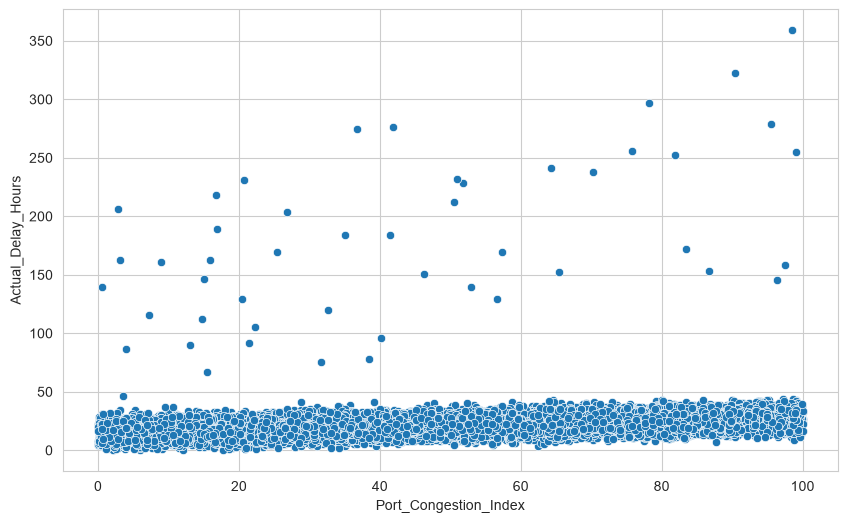

In [19]:
sns.scatterplot(
    data=df,
    x="Port_Congestion_Index",
    y="Actual_Delay_Hours"
)

plt.show()

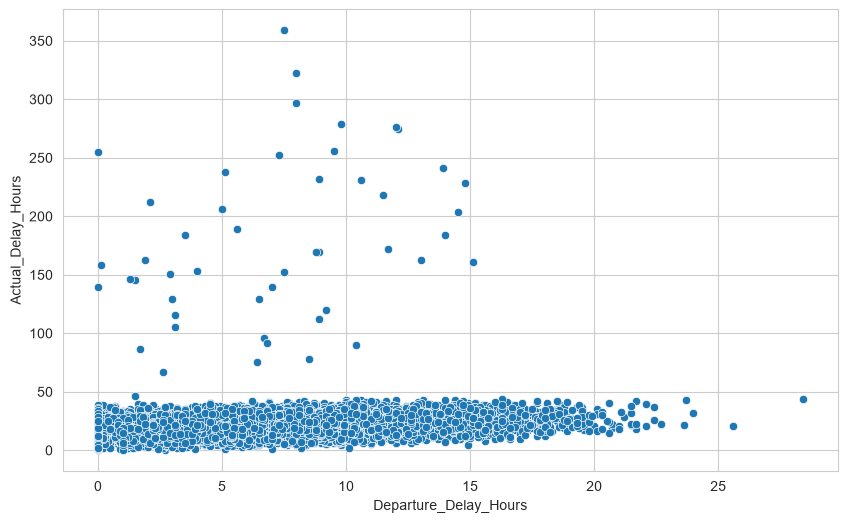

In [20]:
sns.scatterplot(
    data=df,
    x="Departure_Delay_Hours",
    y="Actual_Delay_Hours"
)

plt.show()

# Business Insights from EDA

## Dataset Overview
- Total records: 15,100
- Features: 20
- Target: Late_Arrival

## Data Quality
- Approximately 3% missing values in selected numerical columns.
- 100 duplicate records were intentionally introduced.
- Inconsistent carrier names (e.g., "Maersk" vs "maersk") are present.

## Target Distribution
- The dataset appears reasonably balanced for binary classification.
- No severe class imbalance observed.

## Feature Relationships
- Weather severity shows a positive relationship with actual delay.
- Higher port congestion tends to increase delays.
- Departure delay is strongly associated with arrival delay.
- Actual_Delay_Hours contains realistic outliers.

## Next Steps
- Handle missing values.
- Remove duplicate records.
- Standardize categorical values.
- Prepare data for feature engineering and modeling.